# Pair Selection

Exploratory visualization of the candidate pairs' price series and spreads over the
**formation period only** (2016-01-01 to 2020-12-31). Trading-period data is deliberately
not plotted here (DECISIONS.md ADR-007).

All selection logic lives in `src/cointegration.py` and is run by `scripts/select_pair.py`;
this notebook only inspects its output. The full record of every pair tested is in
`docs/pair_selection.md` and `data/dataset_manifest.json`.

Run `python scripts/select_pair.py` first.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

from src import config
from src.data import align_prices, load_raw, slice_period

raw = load_raw(config.RAW_PRICES_PATH)
full, report = align_prices(raw["Adj Close"], config.UNIVERSE)
formation = slice_period(full, config.FORMATION_START, config.FORMATION_END)
del full  # keep trading-period prices out of this notebook
manifest = json.loads(config.MANIFEST_PATH.read_text(encoding="utf-8"))
results = pd.DataFrame(manifest["pairs_tested"])
print(f"Formation: {formation.index[0].date()} to {formation.index[-1].date()}, {len(formation)} rows")
print(f"Pairs tested: {manifest['n_pairs_tested']}; selected: {manifest['selected_pair']}")

Formation: 2016-01-04 to 2020-12-31, 1259 rows
Pairs tested: 28; selected: EOG/FANG


In [2]:
cols = ["rank", "pair", "eg_stat", "p_raw", "p_holm", "p_bonferroni", "beta", "p_raw_reverse"]
results[cols].round(4)

,rank,pair,eg_stat,p_raw,p_holm,p_bonferroni,beta,p_raw_reverse
0,1,EOG/FANG,-4.1046,0.0051,0.1418,0.1418,0.7423,0.0036
1,2,FANG/OXY,-3.9499,0.0085,0.2283,0.2367,0.7012,0.0491
2,3,APA/DVN,-3.4841,0.0338,0.8795,0.9472,1.0970,0.0468
3,4,EOG/OXY,-3.4363,0.0385,0.9619,1.0000,0.5267,0.0824
4,5,COP/CVX,-3.3953,0.0429,1.0000,1.0000,1.4457,0.0081
5,6,OXY/XOM,-3.3244,0.0515,1.0000,1.0000,2.4336,0.0432
6,7,FANG/XOM,-3.2694,0.0591,1.0000,1.0000,1.7479,0.1663
7,8,CVX/XOM,-3.1561,0.0776,1.0000,1.0000,0.3662,0.9613
8,9,CVX/OXY,-3.0536,0.0980,1.0000,1.0000,0.1324,0.8973
9,10,CVX/EOG,-2.8368,0.1543,1.0000,1.0000,0.3232,0.9126


## Formation-period prices, rebased to 1 on the first day (log scale)

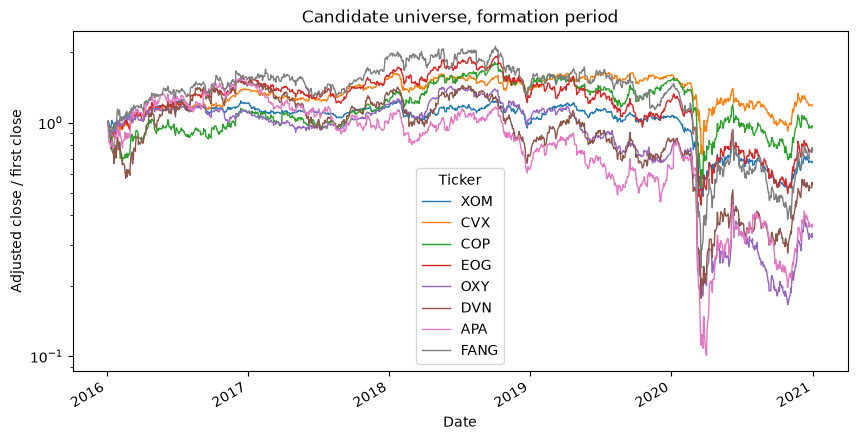

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
(formation / formation.iloc[0]).plot(ax=ax, logy=True, linewidth=1)
ax.set_ylabel("Adjusted close / first close")
ax.set_title("Candidate universe, formation period")
plt.show()

## Formation-period spreads for all 28 pairs

Spread = log(Y) - beta * log(X) - alpha, with the formation-period OLS fit. Because these
residuals are fitted in-sample, they average zero by construction; the shape (how quickly
they return to zero) is what the Engle-Granger test assesses.

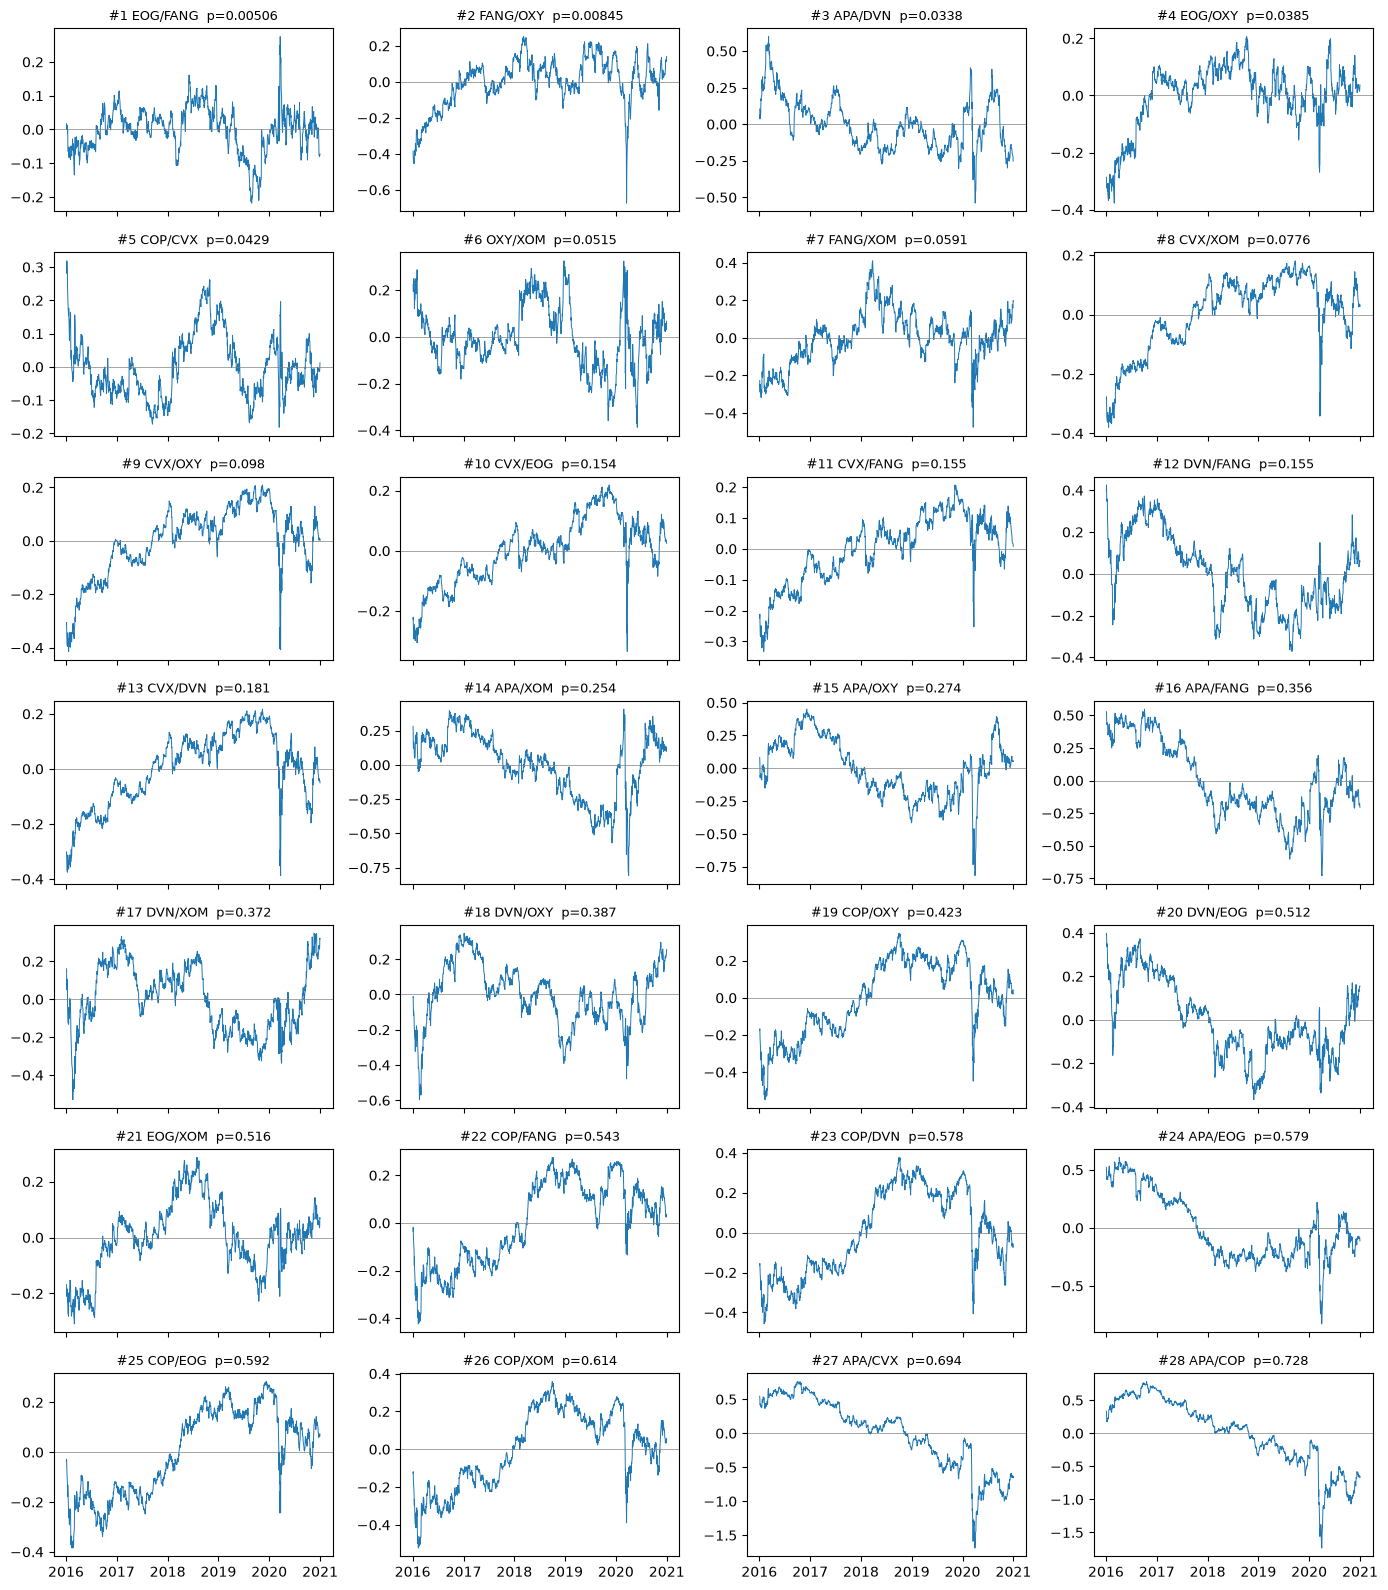

In [4]:
log_f = np.log(formation)
fig, axes = plt.subplots(7, 4, figsize=(14, 16), sharex=True)
for ax, row in zip(axes.flat, results.sort_values("rank").itertuples()):
    spread = log_f[row.y] - row.beta * log_f[row.x] - row.alpha
    ax.plot(spread.index, spread.values, linewidth=0.7)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_title(f"#{row.rank} {row.pair}  p={row.p_raw:.3g}", fontsize=9)
fig.tight_layout()
plt.show()